In [ ]:
from langgraph.graph.message import add_messages
from typing import Annotated
from typing_extensions import TypedDict


"""
WITH add_messages (Your current code): LangGraph sees the new AIMessage and appends it to the existing list. The final state of your graph becomes [HumanMessage(...), AIMessage(...)]. Both the question and the answer are preserved in the final output.
WITHOUT add_messages: If your state was just defined as messages: list without a reducer, LangGraph would completely overwrite the old state with the new one. The final state of your graph would only be [AIMessage(...)]. The original question from the user would be erased from the state the moment the LLM responded!

"""

class State(TypedDict):
    messages: Annotated[list, add_messages] # whenever a node returns a new value for messages, don't overwrite the list — append to it instead."

In [2]:
from langchain_groq import ChatGroq
from dotenv import find_dotenv
from dotenv import load_dotenv
# Load environment variables (ensure GROQ_API_KEY is set in your .env)
load_dotenv(find_dotenv())

# Initialize Groq model
llm = ChatGroq(
    model="qwen/qwen3.8-27b",
    temperature=0.7,
)

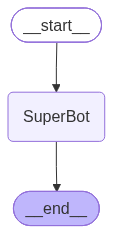

In [6]:
from langgraph.constants import END
from langgraph.constants import START

from langgraph.graph import StateGraph

def superbot(state: State):
    return {'messages': [llm.invoke(state['messages'])]}

graph = StateGraph(State)

graph.add_node("SuperBot", superbot)
graph.add_edge(START, "SuperBot")
graph.add_edge("SuperBot", END)

graph_builder = graph.compile()
graph_builder

In [7]:
response = graph_builder.invoke({'messages': 'Hi, My Name is Arpit and I like cricket'})
response

{'messages': [HumanMessage(content='Hi, My Name is Arpit and I like cricket', additional_kwargs={}, response_metadata={}, id='420ad65d-166b-4b85-9014-026beb2be40a'),
  AIMessage(content='Hi Arpit! Nice to meet you. 🏏\n\nCricket is a fantastic sport with such rich history and passion. Are you a fan of any specific teams or players? Do you prefer watching live matches, following stats, or maybe you play yourself?\n\nI’d love to hear more about what you enjoy most about cricket! 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 71, 'prompt_tokens': 23, 'total_tokens': 94, 'completion_time': 0.139230197, 'completion_tokens_details': None, 'prompt_time': 0.001716978, 'prompt_tokens_details': None, 'queue_time': 0.050118341, 'total_time': 0.140947175}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_4560dae850', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0a821-f9dc-7a80-9e38-b96

In [8]:
for event in graph_builder.stream({'messages': 'Hello I like to eat Poha'}):
    print(event)

{'SuperBot': {'messages': [AIMessage(content='Hello! That’s a wonderful choice. **Poha** (also spelled *Phana* or *Pohe*) is one of the most beloved and comforting breakfast dishes in India, particularly popular in Maharashtra.\n\nIt’s light, nutritious, and incredibly versatile. Do you prefer it with a specific style? For example:\n\n*   **Plain Poha**: Just with tempered spices (mustard seeds, cumin, curry leaves), onions, and peanuts.\n*   **Aloo Poha**: With added potatoes for heartiness.\n*   **Poha Chivda**: Mixed with chivda (spiced fried snacks) and sev for extra crunch.\n*   **Chocolate Poha**: A fun, innovative twist!\n\nDo you have a favorite way to make or eat it? 😊🍛', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 169, 'prompt_tokens': 19, 'total_tokens': 188, 'completion_time': 0.320715838, 'completion_tokens_details': None, 'prompt_time': 0.001023536, 'prompt_tokens_details': None, 'queue_time': 0.051990863, 'total_time': 0.321739374}, 'mod

In [9]:
response = graph_builder.invoke({'messages': 'What is my name and what i play?'})
response

{'messages': [HumanMessage(content='What is my name and what i play?', additional_kwargs={}, response_metadata={}, id='5430f6e2-46fa-4d7c-876d-babbf11ce977'),
  AIMessage(content='I don’t have access to your personal identity, so I don’t know your name or what games you play.\n\nHowever, if you’d like, you can share that information with me, and I’ll be happy to chat about your favorite games or help with anything else! 🎮', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 60, 'prompt_tokens': 21, 'total_tokens': 81, 'completion_time': 0.113716627, 'completion_tokens_details': None, 'prompt_time': 0.001216255, 'prompt_tokens_details': None, 'queue_time': 0.051822115, 'total_time': 0.114932882}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_21e59ac2de', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0a824-c6dd-7e22-8afb-0320d32da61b-0', tool_calls=[], invalid_tool_calls=[], usage